In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## target.csv

In [2]:
target_df = pd.read_csv('target.csv')

In [3]:
target_df['customer_id'].is_unique

True

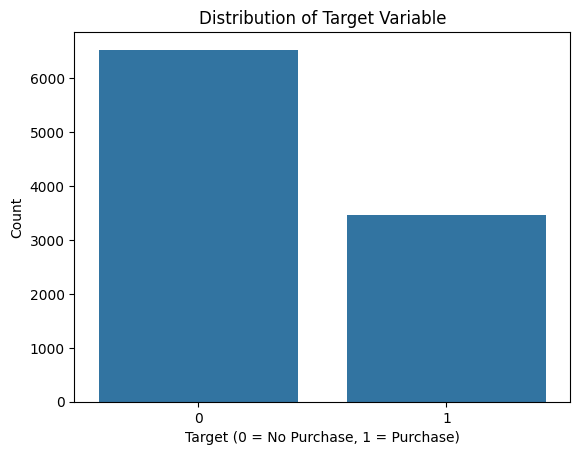

In [4]:
plt.figure()
sns.countplot(x='target', data=target_df)
plt.title('Distribution of Target Variable')
plt.xlabel('Target (0 = No Purchase, 1 = Purchase)')
plt.ylabel('Count')
plt.show()

## customer_sales.csv

In [5]:
customer_sales_df = pd.read_csv('customer_sales.csv')

In [6]:
customer_sales_df['customer_id'].is_unique

False

In [7]:
customer_sales_df = customer_sales_df.drop_duplicates()

In [8]:
customer_sales_df['customer_id'].is_unique

True

## logic checks

In [9]:
spend_columns = [
    'spend_cat_home', 'spend_cat_garden', 'spend_cat_sports',
    'spend_cat_clothing', 'spend_cat_gifts', 'spend_cat_beauty',
    'spend_cat_shoes', 'spend_cat_garden_accessories'
]

customer_sales_df['calculated_total_spend'] = customer_sales_df[spend_columns].sum(axis=1).round(2)
customer_sales_df['spend_difference'] = (customer_sales_df['calculated_total_spend'] - customer_sales_df['total_spend']).round(2)
customer_sales_df['spend_difference'].value_counts()

spend_difference
 0.00         6105
 0.01         1804
-0.01         1788
 0.02          155
-0.02          145
 0.03            2
 399702.22       1
Name: count, dtype: int64

### outliers

In [10]:
customer_sales_df[customer_sales_df['spend_difference'] == 399702.22]

,customer_id,spend_cat_home,spend_cat_garden,spend_cat_sports,spend_cat_clothing,spend_cat_gifts,spend_cat_beauty,spend_cat_shoes,spend_cat_garden_accessories,transactions_cat_home,...,last_purchase_date_clothing,last_purchase_date_gifts,last_purchase_date_sports,last_purchase_date_beauty,last_purchase_date_shoes,total_spend,total_transactions,last_purchase_date_all,calculated_total_spend,spend_difference
7994,17894,99999.0,99999.0,0.0,0.0,0.0,99999.0,99999.0,0.0,99999.0,...,NaN,NaN,NaN,NaN,NaN,293.78,0.0,NaN,399996.0,399702.22


In [11]:
customer_sales_df.drop(customer_sales_df[customer_sales_df['customer_id'] == 17894].index, inplace=True)

In [12]:
transactions_columns = [
    'transactions_cat_home', 'transactions_cat_garden',
    'transactions_cat_sports', 'transactions_cat_clothing',
    'transactions_cat_gifts', 'transactions_cat_beauty',
    'transactions_cat_shoes', 'transactions_cat_garden_accessories'
]

customer_sales_df['calculated_total_transactions'] = customer_sales_df[transactions_columns].sum(axis=1)
customer_sales_df['transactions_difference'] = (customer_sales_df['calculated_total_transactions'] - customer_sales_df['total_transactions'])
customer_sales_df['transactions_difference'].value_counts()

transactions_difference
0.0    9999
Name: count, dtype: int64

In [13]:
last_purchase_columns = [
    'last_purchase_date_home', 'last_purchase_date_garden',
    'last_purchase_date_sports', 'last_purchase_date_clothing',
    'last_purchase_date_gifts', 'last_purchase_date_beauty', 
    'last_purchase_date_shoes'
]

# NOTE: there is not data for garden accessories

customer_sales_df[last_purchase_columns] = customer_sales_df[last_purchase_columns].apply(pd.to_datetime, errors='coerce')
customer_sales_df['last_purchase_date_all'] = customer_sales_df['last_purchase_date_all'].apply(pd.to_datetime, errors='coerce')

customer_sales_df['calculated_last_purchase_date_all'] = customer_sales_df[last_purchase_columns].max(axis=1)
customer_sales_df['last_purchase_date_difference'] = customer_sales_df['calculated_last_purchase_date_all'] - customer_sales_df['last_purchase_date_all']

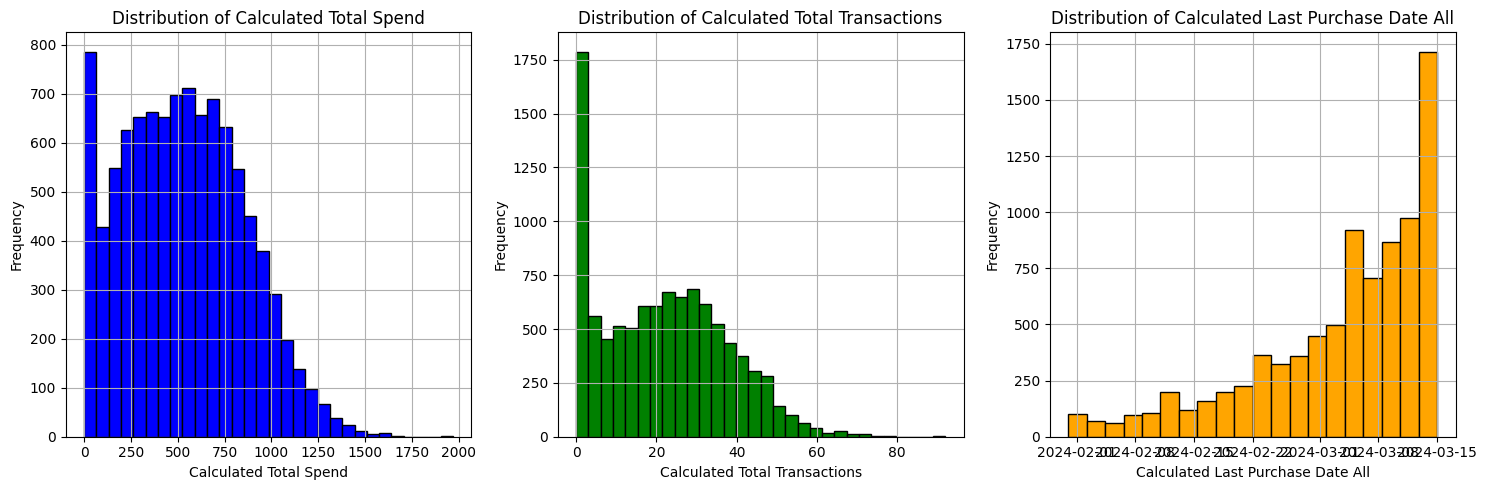

In [14]:
plt.figure(figsize=(15, 5))

# Plot for 'calculated_total_spend'
plt.subplot(1, 3, 1)
customer_sales_df['calculated_total_spend'].hist(bins=30, color='blue', edgecolor='black')
plt.title('Distribution of Calculated Total Spend')
plt.xlabel('Calculated Total Spend')
plt.ylabel('Frequency')

# Plot for 'calculated_total_transactions'
plt.subplot(1, 3, 2)
customer_sales_df['calculated_total_transactions'].hist(bins=30, color='green', edgecolor='black')
plt.title('Distribution of Calculated Total Transactions')
plt.xlabel('Calculated Total Transactions')
plt.ylabel('Frequency')

# Plot for 'calculated_last_purchase_date_all'
plt.subplot(1, 3, 3)
customer_sales_df['calculated_last_purchase_date_all'].hist(bins=20, color='orange', edgecolor='black')
plt.title('Distribution of Calculated Last Purchase Date All')
plt.xlabel('Calculated Last Purchase Date All')
plt.ylabel('Frequency')

# Adjust layout and display the plots
plt.tight_layout()
plt.show()

## Inconsistencies

In [15]:
filtered_df = customer_sales_df[(customer_sales_df['calculated_total_spend'] > 0) & (customer_sales_df['calculated_total_transactions'] == 0)]

In [16]:
filtered_df = customer_sales_df[
    (customer_sales_df['calculated_last_purchase_date_all'].isnull()) & 
    (customer_sales_df['calculated_total_spend'] > 0)
]

In [17]:
filtered_df = customer_sales_df[
    (customer_sales_df['spend_cat_shoes'] > 0)
]

## additional.csv

In [18]:
additional_df = pd.read_csv('additional.csv')

In [19]:
additional_df['customer_id'].is_unique

True

## browsing.csv

In [20]:
browsing_df = pd.read_csv('browsing.csv')

In [21]:
browsing_df['category'] = browsing_df['page_view'].str.extract(r'category_(\w+)/')
browsing_df['product_id'] = browsing_df['page_view'].str.extract(r'product_(\d+)')

In [22]:
print(browsing_df.head())

   customer_id                                          page_view category  \
0        10000  /jl/95eea910508d0ced42fba04feafeee/category_gi...    gifts   
1        10000  /jl/0fe035c1b6b49589073aa14e4c356e/category_ho...     home   
2        10000  /jl/83fa826d2313a013e331b250ca8b14/category_ga...   garden   
3        10000  /jl/3e06ecb6b1aa6757d6c7c88cbd6101/category_ga...   garden   
4        10000  /jl/e86f4ca57f99961c4570d41e6b1466/category_gi...    gifts   

  product_id  
0      81073  
1      66287  
2      88329  
3      35937  
4      72308  


In [23]:
# Calculate the number of views per category
cust_browsing_df = (
    browsing_df.groupby(['customer_id', 'category'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

cust_browsing_df.columns = ['customer_id'] + [f"{cat}_views" for cat in cust_browsing_df.columns[1:]]

In [24]:
# List of view columns to sum
view_columns = ['beauty_views', 'clothing_views', 'garden_views', 'gifts_views', 'home_views']

# Create a new column 'total_views' by summing the view columns for each row
cust_browsing_df['total_views'] = cust_browsing_df[view_columns].sum(axis=1)
cust_browsing_df = cust_browsing_df.drop(['beauty_views', 'clothing_views', 'garden_views', 'gifts_views'], axis=1)

In [25]:
cust_product_views_df = (
    browsing_df.groupby(['customer_id', 'category'])['product_id']
    .nunique()
    .unstack(fill_value=0)
    .reset_index()
)

# Rename the columns to indicate product counts
cust_product_views_df.columns = ['customer_id'] + [f"products_{cat}" for cat in cust_product_views_df.columns[1:]]

# Display the resulting DataFrame
cust_product_views_df.head()

,customer_id,products_beauty,products_clothing,products_garden,products_gifts,products_home
0,10000,0,1,3,2,3
1,10001,0,0,2,0,3
2,10002,0,1,4,0,6
3,10003,0,1,1,0,0
4,10004,1,2,3,1,3


In [26]:
# List of view columns to sum
product_columns = ['products_beauty', 'products_clothing', 'products_garden', 'products_gifts', 'products_home']

# Create a new column 'total_views' by summing the view columns for each row
cust_product_views_df['total_products'] = cust_product_views_df[product_columns].sum(axis=1)
cust_product_views_df = cust_product_views_df.drop(['products_beauty', 'products_clothing', 'products_garden', 'products_gifts'], axis=1)
cust_product_views_df.head()

,customer_id,products_home,total_products
0,10000,3,9
1,10001,3,5
2,10002,6,11
3,10003,0,2
4,10004,3,10


In [27]:
browsing_df_simple = pd.merge(cust_browsing_df, cust_product_views_df, on='customer_id')
browsing_df_simple

,customer_id,home_views,total_views,products_home,total_products
0,10000,3,9,3,9
1,10001,3,7,3,5
2,10002,8,15,6,11
3,10003,0,2,0,2
4,10004,5,12,3,10
...,...,...,...,...,...
8360,19995,3,7,3,7
8361,19996,7,17,6,12
8362,19997,1,2,1,2
8363,19998,3,3,3,3


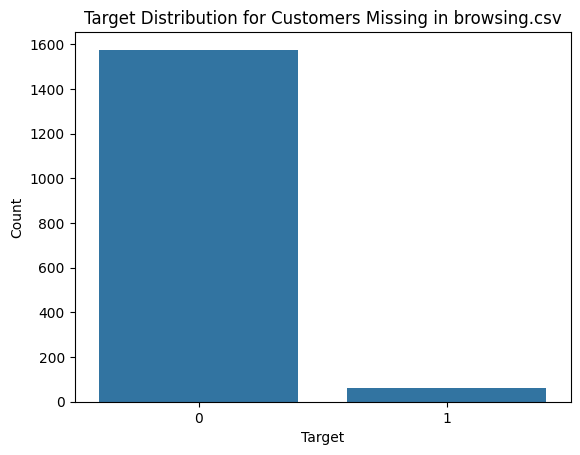

In [28]:
missing_customers = set(target_df['customer_id']) - set(browsing_df['customer_id'])

missing_customers_data = target_df[target_df['customer_id'].isin(missing_customers)]

plt.figure()
sns.countplot(x='target', data=missing_customers_data)
plt.title('Target Distribution for Customers Missing in browsing.csv')
plt.xlabel('Target')
plt.ylabel('Count')
plt.show()

## demographics.csv

In [29]:
demographics_df = pd.read_csv('demographics.csv')

In [30]:
demographics_df[
    ~demographics_df['affluence'].isin([1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0]) |
    ~demographics_df['hh_size'].isin([1.0, 2.0, 3.0, 4.0]) |
    ~demographics_df['customer_segment'].isin([1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0])
]

,customer_id,affluence,hh_size,customer_segment
6385,17894,99999.0,99999.0,99999.0


In [31]:
demographics_df.drop(demographics_df[demographics_df['customer_id'] == 17894].index, inplace=True)

In [32]:
demographics_df['customer_id'].is_unique

True

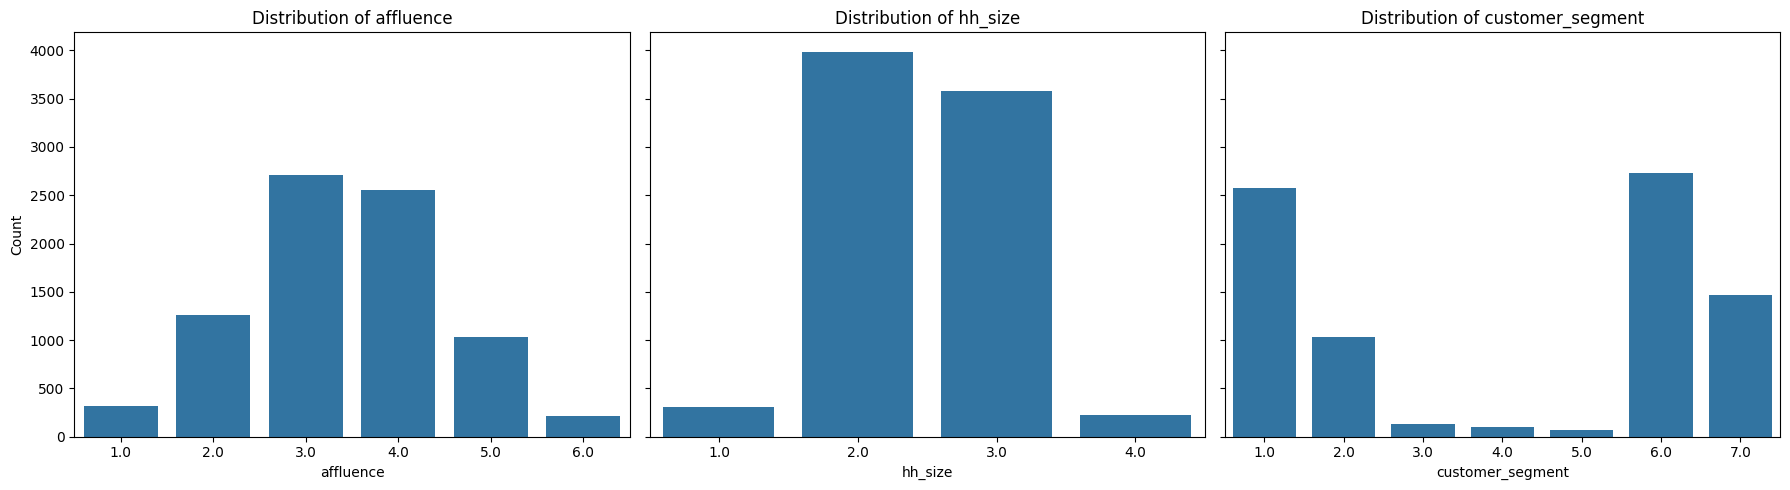

In [33]:
columns = ['affluence', 'hh_size', 'customer_segment']

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, col in zip(axes, columns):
    sns.countplot(x=col, data=demographics_df, ax=ax)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

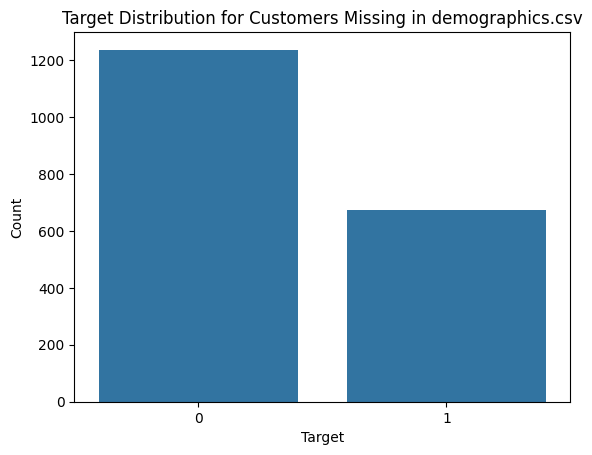

In [34]:
missing_customers = set(target_df['customer_id']) - set(demographics_df['customer_id'])

missing_customers_data = target_df[target_df['customer_id'].isin(missing_customers)]

plt.figure()
sns.countplot(x='target', data=missing_customers_data)
plt.title('Target Distribution for Customers Missing in demographics.csv')
plt.xlabel('Target')
plt.ylabel('Count')
plt.show()

DO MORE HERE

### update combined_df

In [35]:
combined_df = pd.merge(target_df, customer_sales_df, on='customer_id', how='inner')

In [36]:
combined_df = pd.merge(combined_df, additional_df, on='customer_id', how='inner')

In [37]:
combined_df = pd.merge(combined_df, browsing_df_simple, on='customer_id', how='left')

In [38]:
#combined_df = pd.merge(combined_df, demographics_df, on='customer_id', how='left')

In [39]:
combined_df['calculated_total_spend_ex_home'] = combined_df['calculated_total_spend'] - combined_df['spend_cat_home']
reference_date = pd.Timestamp('2024-03-16')
combined_df['days_since_last_home_purchase'] = (reference_date - combined_df['last_purchase_date_home']).dt.days.astype(float)
combined_df['total_views_ex_home'] = combined_df['total_views'] - combined_df['home_views']
combined_df['binary_browsing'] = combined_df['total_views'].notnull().astype(int)

In [40]:
combined_df.to_csv('combined_df.csv', index=False)